# Visualizing MESA reactions

In [1]:
import pynucastro as pyna
import mesa_reader as mr

In [2]:
from pynucastro import mesa_utils
from pynucastro.screening import chugunov_2007

## Read in the MESA model

In [3]:
model = mr.MesaData("profile2.data")

In [4]:
nuclei = mesa_utils.get_nuclei(model)
nuclei

[H1,
 He4,
 O16,
 O20,
 F20,
 Ne20,
 Ne23,
 Ne24,
 Ne25,
 Na23,
 Na24,
 Na25,
 Mg24,
 Mg25,
 Si28]

In [5]:
mesa_zones = mesa_utils.get_all_data(model)

## Create the network using the same species as the MESA model

By default, `network_helper` will find all the rates connecting the nuclei, some of which were likely not used in the MESA simulation.

In [6]:
net = pyna.network_helper(nuclei)

In [7]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 15
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  total number of rates: 38

  rates explicitly connecting nuclei: 38
  hidden rates: 0

  reaclib rates: 12
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 14
  approximate rates: 0
  derived rates: 12
  modified rates: 0
  custom rates: 0


We can see the structure of the network

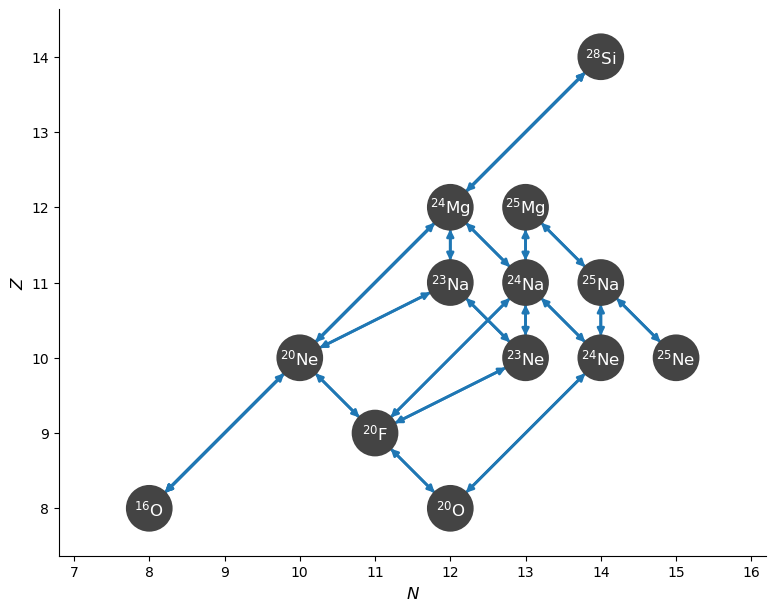

In [8]:
fig = net.plot()

and the rates and their sources

In [9]:
for r in net.rates:
    print(f"{r!s:30} : {r.source['Label']}")

O16 + He4 ⟶ Ne20 + 𝛾           : co10
O20 + He4 ⟶ Ne24 + 𝛾           : rpsm
F20 + He4 ⟶ Na24 + 𝛾           : rpsm
Ne20 + He4 ⟶ Mg24 + 𝛾          : il10
Ne23 + p ⟶ Na24 + 𝛾            : rath
Ne24 + p ⟶ Na25 + 𝛾            : rath
Na23 + p ⟶ Mg24 + 𝛾            : il10
Na24 + p ⟶ Mg25 + 𝛾            : rath
Mg24 + He4 ⟶ Si28 + 𝛾          : st08
O16 + O16 ⟶ He4 + Si28         : cf88
F20 + He4 ⟶ p + Ne23           : rpsm
Na23 + p ⟶ He4 + Ne20          : il10
Ne20 ⟶ He4 + O16               : co10
Ne24 ⟶ He4 + O20               : rpsm
Na24 ⟶ p + Ne23                : rath
Na24 ⟶ He4 + F20               : rpsm
Na25 ⟶ p + Ne24                : rath
Mg24 ⟶ p + Na23                : il10
Mg24 ⟶ He4 + Ne20              : il10
Mg25 ⟶ p + Na24                : rath
Si28 ⟶ He4 + Mg24              : st08
Ne20 + He4 ⟶ p + Na23          : il10
Ne23 + p ⟶ He4 + F20           : rpsm
Si28 + He4 ⟶ O16 + O16         : cf88
F20 ⟶ Ne20 + e⁻ + 𝜈            : suzuki
F20 + e⁻ ⟶ O20 + 𝜈             : suzuki
Ne20 + e

The Suzuki rates are not valid for $\rho Y_e < 10^7~\mathrm{g~cm^{-3}}$, so let's find the model index that corresponds to

In [10]:
i_cutoff = min(i for i in range(len(mesa_zones)) if mesa_zones[i][0] * mesa_zones[i][-1].ye > 1.e7)

## A network plot

Here's a function that takes a zone index and makes a plot

In [27]:
def _make_plot(i_zone, curved_edges=False, legend=False):
    if curved_edges:
        use_net_rate = False
    else:
        use_net_rate = True
    if legend:
        legend_coord = (11.5, 8.5)
    else:
        legend_coord = None
    rho, T, comp = mesa_zones[i_zone]
    fig = net.plot(rho=rho, T=T, comp=comp,
                   screen_func=chugunov_2007,
                   use_net_rate=use_net_rate, curved_edges=curved_edges,
                   ydot_cutoff_value=1.e-30,
                   legend_coord=legend_coord,
                   show_small_ydot=True,               
                   color_nodes_by_abundance=True)
    fig.text(0.1, 0.9, rf"T = {T:6.3g} K, $\rho$ = {rho:6.3g} g/cm$^3$", transform=fig.transFigure)
    fig.text(0.1, 0.925, f"zone = {i_zone}", transform=fig.transFigure)

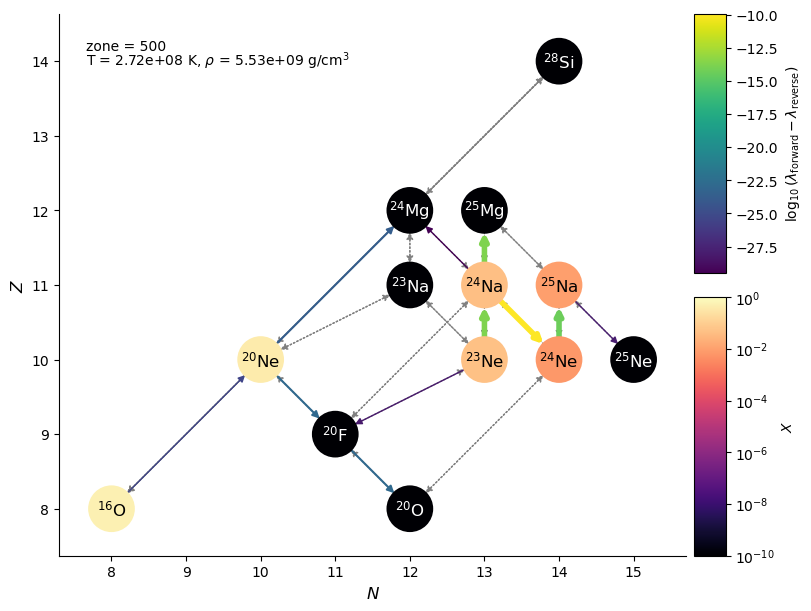

In [28]:
_make_plot(500)

## Interactive plot

We can make the plot interactive by using `ipywidgets`

In [29]:
from ipywidgets import interact

In [30]:
interact(_make_plot, i_zone=(i_cutoff, len(mesa_zones)-1, 1), curved_edges=False)

interactive(children=(IntSlider(value=541, description='i_zone', max=785, min=298), Checkbox(value=False, desc…

<function __main__._make_plot(i_zone, curved_edges=False, legend=False)>